In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns


%matplotlib inline
matplotlib.rcParams['figure.figsize']=(12,8) 
sns.set_style('whitegrid')

In [7]:
# load dataset
df=pd.read_csv('Tetuan City power consumption.csv')

## Exploratory Analysis

In [8]:
# preliminary information about the dataset
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')

Number of Rows: 52416
Number of Columns: 9


In [9]:
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [10]:
# check data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  object 
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB
None


- the DateTime column has to be changed from an object to a datetime datatype for time series analysis and forecasting.
- make the DateTime column the index

In [11]:
df['DateTime']= df['DateTime'].astype(str)
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.index= df['DateTime']
print('Applied')
print(f'DateTime data type: {df["DateTime"].dtype}')

Applied
DateTime data type: datetime64[ns]


In [12]:
# checking for missing values

def nullvalues(df1):
    """ Generates a DataFrame summarizing the count and percentage of null values for each column in the input Data"""
    nulldf=pd.DataFrame({
        #'Columns':df1.columns,
        'Null Count': df1.isnull().sum(),
        'Null Percentage(%)': (df1.isnull().sum() *100/len(df1)).round(2)
    }).sort_values(by='Null Percentage(%)', ascending=False)
    print(nulldf)

nullvalues(df)

                           Null Count  Null Percentage(%)
DateTime                            0                 0.0
Temperature                         0                 0.0
Humidity                            0                 0.0
Wind Speed                          0                 0.0
general diffuse flows               0                 0.0
diffuse flows                       0                 0.0
Zone 1 Power Consumption            0                 0.0
Zone 2  Power Consumption           0                 0.0
Zone 3  Power Consumption           0                 0.0


In [13]:
# general descriptive statistics
df.describe().T

,count,mean,min,25%,50%,75%,max,std
DateTime,52416,2017-07-01 23:55:00,2017-01-01 00:00:00,2017-04-01 23:57:30,2017-07-01 23:55:00,2017-09-30 23:52:30,2017-12-30 23:50:00,NaN
Temperature,52416.0,18.810024,3.247,14.41,18.78,22.89,40.01,5.815476
Humidity,52416.0,68.259518,11.34,58.31,69.86,81.4,94.8,15.551177
Wind Speed,52416.0,1.959489,0.05,0.078,0.086,4.915,6.483,2.348862
general diffuse flows,52416.0,182.696614,0.004,0.062,5.0355,319.6,1163.0,264.40096
diffuse flows,52416.0,75.028022,0.011,0.122,4.456,101.0,936.0,124.210949
Zone 1 Power Consumption,52416.0,32344.970564,13895.6962,26310.668692,32265.92034,37309.018185,52204.39512,7130.562564
Zone 2 Power Consumption,52416.0,21042.509082,8560.081466,16980.766032,20823.168405,24713.71752,37408.86076,5201.465892
Zone 3 Power Consumption,52416.0,17835.406218,5935.17407,13129.32663,16415.11747,21624.10042,47598.32636,6622.165099


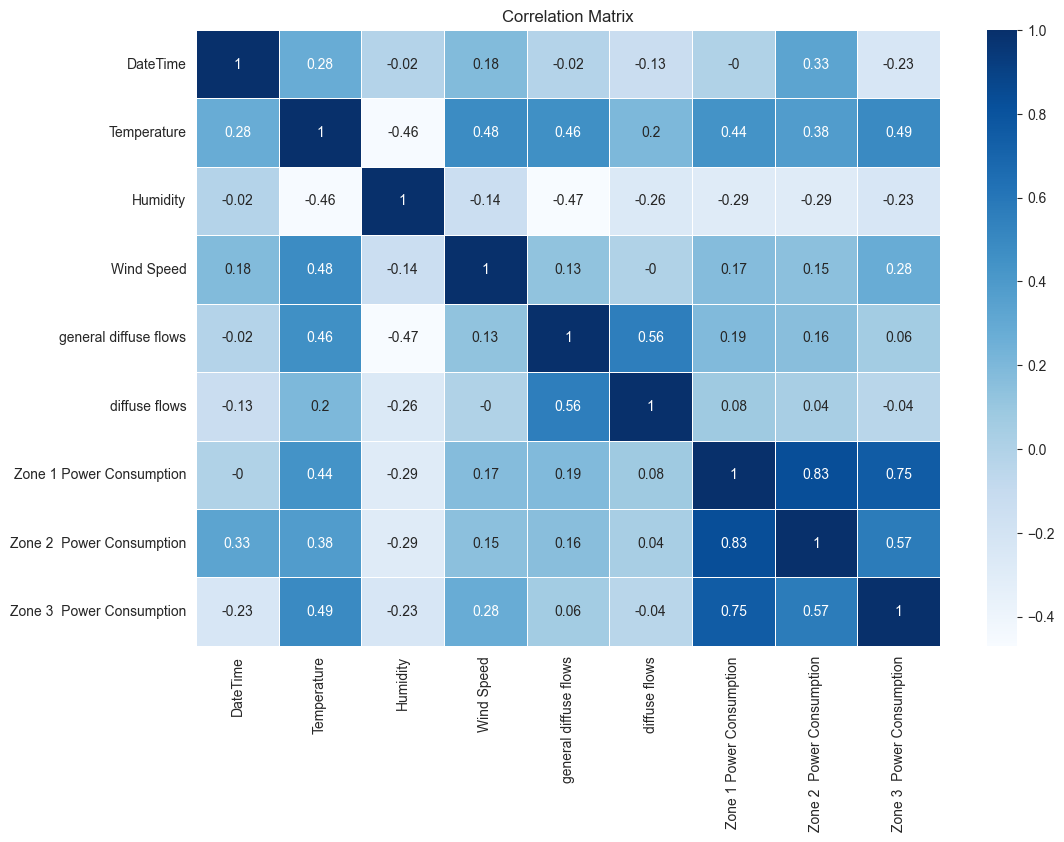

In [14]:
# checking correlation statistics
corr_matrix=df.corr('pearson').round(2)
sns.heatmap(corr_matrix,annot=True, cmap='Blues', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## Data Processing and Feature Engineering

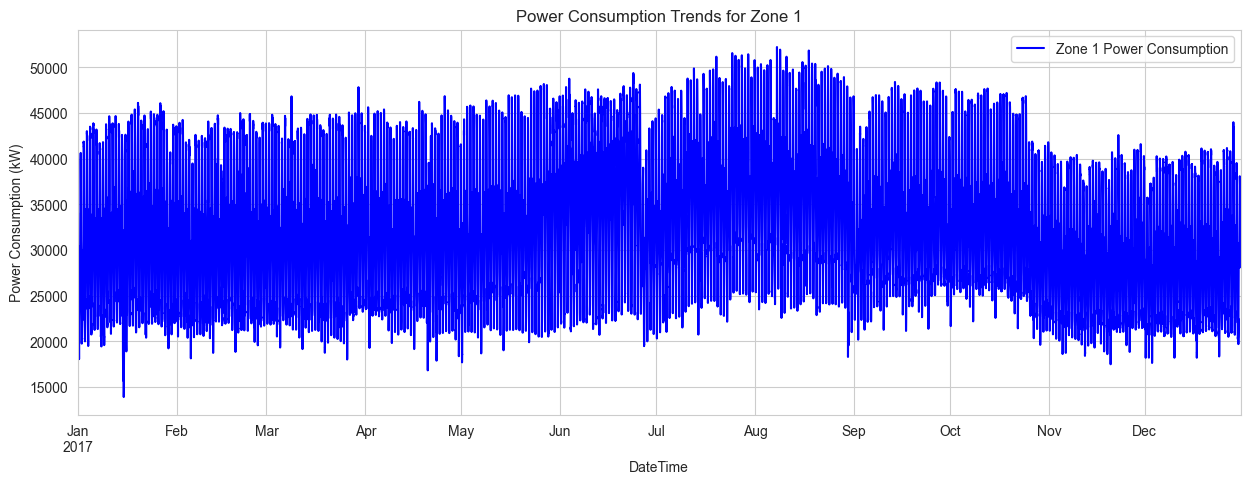

In [15]:
# Power consumption trends for each zone in Tetouan City
zone1=df.filter(items=['Zone 1 Power Consumption'])

zone1.plot(label='Zone 1 Power Consumption', color='blue',figsize=(15,5))
plt.title('Power Consumption Trends for Zone 1')
plt.ylabel('Power Consumption (kW)')
plt.show()

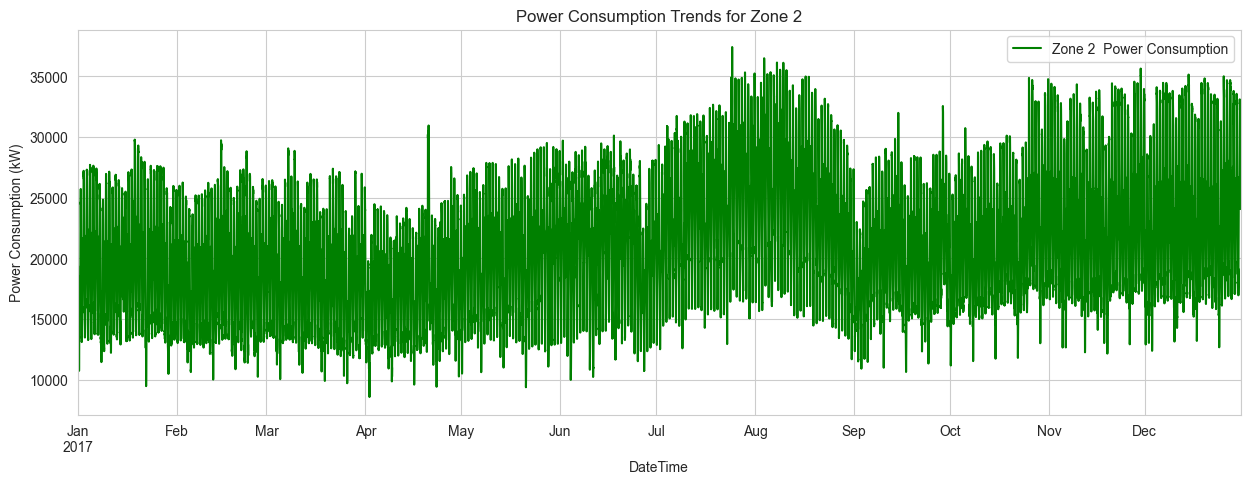

In [16]:
# Zone 2 Power Consumption Trends
zone2=df.filter(items=['Zone 2  Power Consumption'])

zone2.plot(label='Zone 2 Power Consumption', color='green',figsize=(15,5))
plt.title('Power Consumption Trends for Zone 2')
plt.ylabel('Power Consumption (kW)')
plt.show()

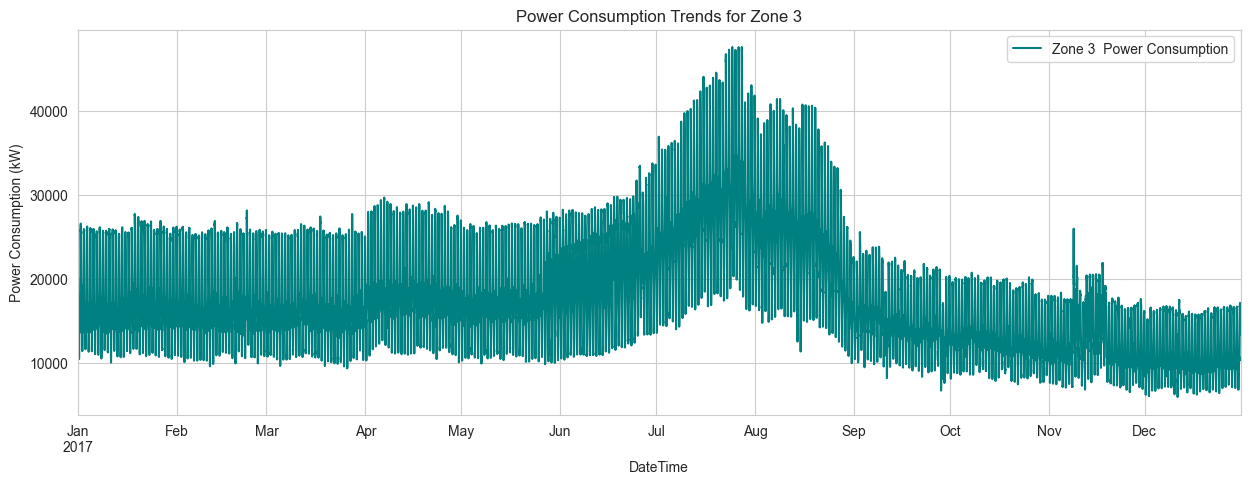

In [17]:
# Zone 3 Power Consumption Trends
zone3=df.filter(items=['Zone 3  Power Consumption'])

zone3.plot(label='Zone 3 Power Consumption', color='teal',figsize=(15,5))
plt.title('Power Consumption Trends for Zone 3')
plt.ylabel('Power Consumption (kW)')
plt.show()

There appears to be a seasonal variation in the power consumption for each zone between July and September (more so the end of August) where the power consumption rises significantly.

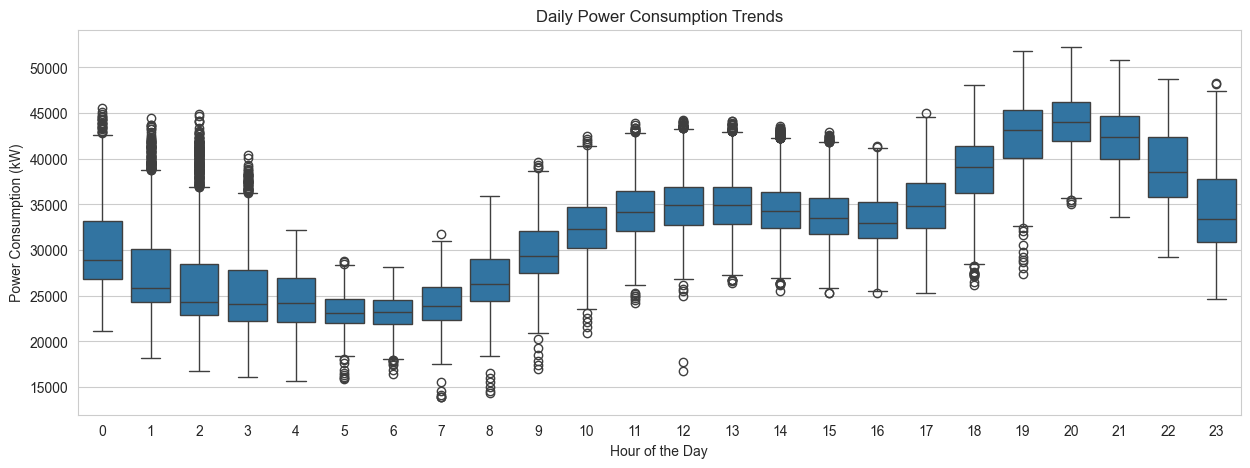

In [18]:
# Daily Power Consumption Trends
# modeled after zone1 due to similarity in power consumption across all zones

fig,ax=plt.subplots(figsize=(15,5))
sns.boxplot(x=df.index.hour, y=df['Zone 1 Power Consumption'])
plt.ylabel('Power Consumption (kW)')
plt.xlabel('Hour of the Day')
plt.title('Daily Power Consumption Trends')
plt.show()

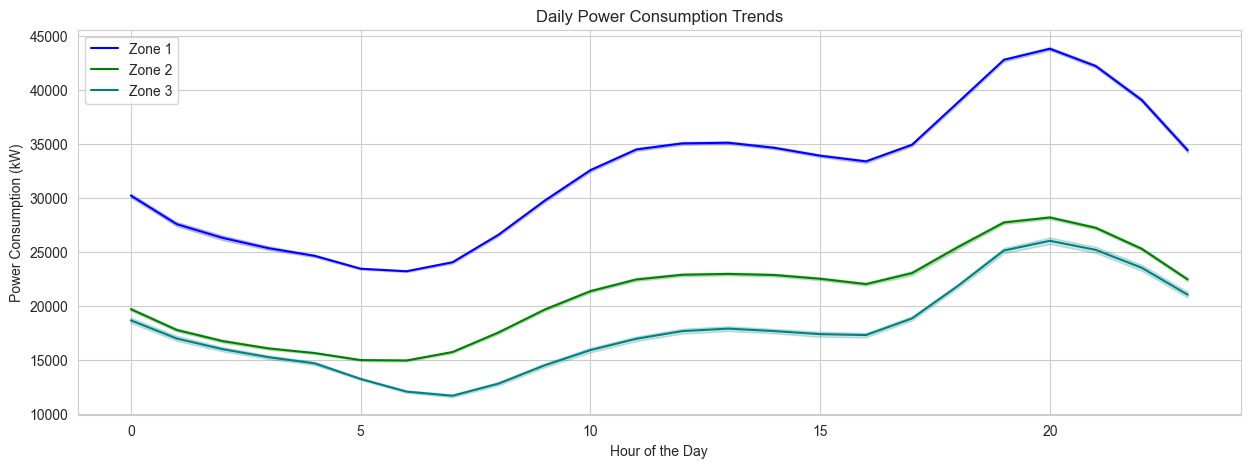

In [19]:
fig,ax=plt.subplots(figsize=(15,5))
sns.lineplot(x=df.index.hour, y=df['Zone 1 Power Consumption'],color='blue',label='Zone 1')
sns.lineplot(x=df.index.hour, y=df['Zone 2  Power Consumption'],color='green',label='Zone 2')
sns.lineplot(x=df.index.hour, y=df['Zone 3  Power Consumption'],color='teal',label='Zone 3')
plt.ylabel('Power Consumption (kW)')
plt.xlabel('Hour of the Day')
plt.title('Daily Power Consumption Trends')
plt.show()

- power consumption seems to peak in the evenings, around 19:00 - 23:00 hrs, and is lowest in the early hours of the morning, around 2:00 - 7:00 hrs

- General trends also show the mean power consumption for zone 3 is the lowest compared to the other zones
- Zone 1 has a higher consumption by a significant margin as compared to the other zones

In [20]:
# import packages for model training and forecasting
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [21]:
hourly_data=df['Zone 1 Power Consumption'].asfreq('h')

# exogenous variables that can affect power consumption forecast
exo_values= ['Temperature','Humidity','Wind Speed','general diffuse flows','diffuse flows']
X=df[exo_values].asfreq('h')

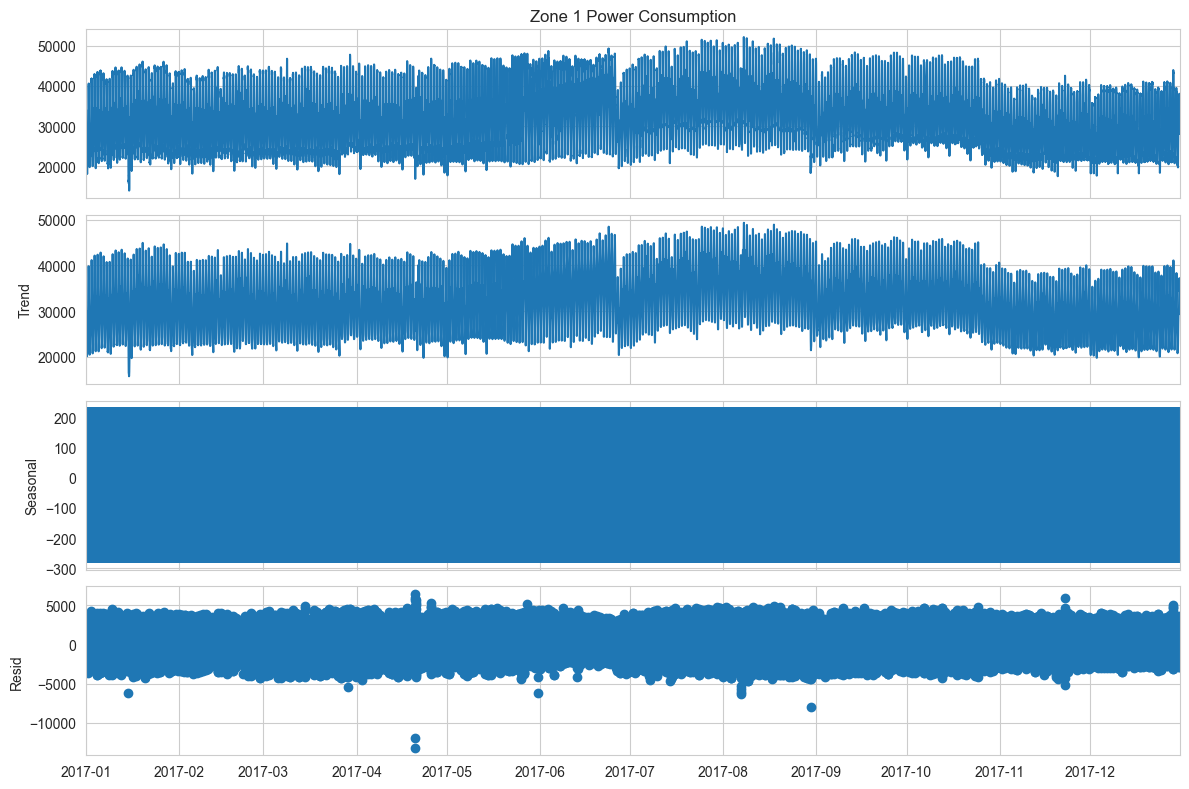

In [22]:
decomp=seasonal_decompose(df['Zone 1 Power Consumption'], model='additive', period=24)
fig=decomp.plot()
fig.set_size_inches(12,8)
plt.show()

In [23]:
# Adfuller analysis to test if data is stationary
def adf_report(series,name):
    """Performs the Augmented Dickey-Fuller test on the input time series and prints the results."""
    result=adfuller(series.dropna())
    return pd.Series({
        'Series': name,
        'adf_statistic': result[0],
        'p_value': result[1],
        'observations': result[3],
        'is_stationary_5pct': result[1] < 0.05
    })


adf_raw=adf_report(hourly_data,'Raw Series')
seasonal_diff=hourly_data.diff(24)
adf_seasonal_diff=adf_report(seasonal_diff,'Seasonally_Differenced_Series')
pd.DataFrame([adf_raw,adf_seasonal_diff])

,Series,adf_statistic,p_value,observations,is_stationary_5pct
0,Raw Series,-4.484081,2.100820e-04,8698,True
1,Seasonally_Differenced_Series,-18.404336,2.189645e-30,8683,True


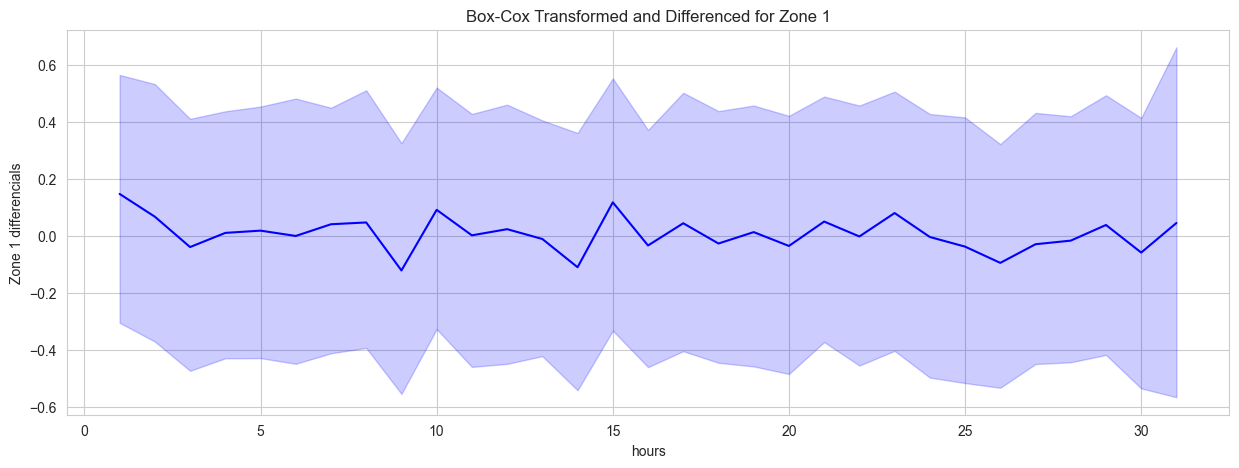

In [24]:
# Making the dataset stationary by applying Box-Cox transformation
df['zone1_BoxCox'], lam = boxcox(df['Zone 1 Power Consumption'])
df['zone1_diff'] = df['zone1_BoxCox'].diff(24)
df['zone1_diff'].dropna()

fig,ax=plt.subplots(figsize=(15,5))
sns.lineplot(x=df.index.day, y=df['zone1_diff'],color='blue')
plt.ylabel('Zone 1 differencials')
plt.xlabel('hours')
plt.title('Box-Cox Transformed and Differenced for Zone 1')
plt.show()

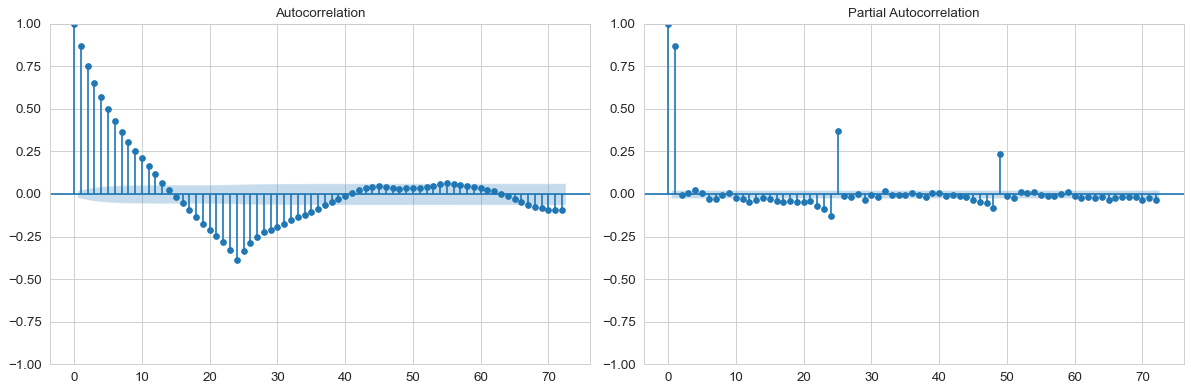

In [25]:
# Deducing the order of ARIMA model using ACF and PACF plots
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,5),dpi=80)
plot_acf(seasonal_diff.dropna(), lags=72,ax=ax1)
plot_pacf(seasonal_diff.dropna(),lags=72,method='ywm',ax=ax2)
ax1.tick_params(axis='both',labelsize=12)
ax2.tick_params(axis='both',labelsize=12)
plt.tight_layout()
plt.show()

## Train-Test Split

In [26]:
# holding out last 14 days for forecasting (24*14=336 hours)
horizon=24*14
y_train,y_test= hourly_data.iloc[:-horizon],hourly_data.iloc[-horizon:]
x_train,x_test= X.iloc[:-horizon],X.iloc[-horizon:]

print('Train Points:', len(y_train))
print('Test Points:', len(y_test))
print('Train Range:', y_train.index.min(), 'to', y_train.index.max())
print('Test Range:', y_test.index.min(), 'to', y_test.index.max())

Train Points: 8400
Test Points: 336
Train Range: 2017-01-01 00:00:00 to 2017-12-16 23:00:00
Test Range: 2017-12-17 00:00:00 to 2017-12-30 23:00:00


## Model Training and Testing

In [27]:
# Order informed by ACF, PACF plots and daily seasonality
order=(1,0,1)
seasonal_order=(1,1,1,24)

model= SARIMAX(
    y_train,
    order=order,
    seasonal_order=seasonal_order,
    trend='n',
    enforce_stationarity=False,
    enforce_invertibility=False
)

# fitting the model
results=model.fit(disp=False)

# model summary
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:           Zone 1 Power Consumption   No. Observations:                 8400
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -68028.905
Date:                            Mon, 11 May 2026   AIC                         136067.811
Time:                                    12:11:07   BIC                         136102.961
Sample:                                01-01-2017   HQIC                        136079.816
                                     - 12-16-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8753      0.004    224.246      0.000       0.868       0.883
ma.L1          0.0186      0.008   

In [28]:
# model taking into account exogenous variables
sarimax=SARIMAX(
    y_train,
    exog= x_train,
    order=order,
    seasonal_order=seasonal_order,
    trend='c',
    enforce_invertibility=False,
    enforce_stationarity=False
)

# model fitting
sarimax_results=sarimax.fit(disp=False)

# model summary
print(sarimax_results.summary())

/Users/franknelson/miniforge3/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:           Zone 1 Power Consumption   No. Observations:                 8400
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -68066.630
Date:                            Mon, 11 May 2026   AIC                         136155.260
Time:                                    12:14:10   BIC                         136232.590
Sample:                                01-01-2017   HQIC                        136181.672
                                     - 12-16-2017                                         
Covariance Type:                              opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept                 1.2813      3.243      0.395      0.693      -5.076       7.638
Te

In [29]:
#Comparing the performance of both models using AIC, BIC, MAE and RMSE metrics
def RMSE(y_true, y_pred):
    """Calculates the Root Mean Squared Error between the true and predicted values."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

sarima_fc=results.get_forecast(steps=horizon).predicted_mean
sarimax_fc=sarimax_results.get_forecast(steps=horizon, exog=x_test).predicted_mean

#comparison of results
comparison=pd.DataFrame([
    {
        'model':'SARIMA',
        'AIC': results.aic,
        'BIC': results.bic,
        'MAE': mean_absolute_error(y_test, sarima_fc),
        'RMSE': RMSE(y_test, sarima_fc)
    },
    {
        'model':'SARIMAX',
        'AIC': sarimax_results.aic,
        'BIC': sarimax_results.bic,
        'MAE': mean_absolute_error(y_test, sarimax_fc),
        'RMSE': RMSE(y_test, sarimax_fc)
    }
]).set_index('model').sort_values(by='RMSE')

comparison

,AIC,BIC,MAE,RMSE
model,,,,
SARIMA,136067.810901,136102.960985,909.666622,1273.225202
SARIMAX,136155.260122,136232.590307,913.097030,1322.431060


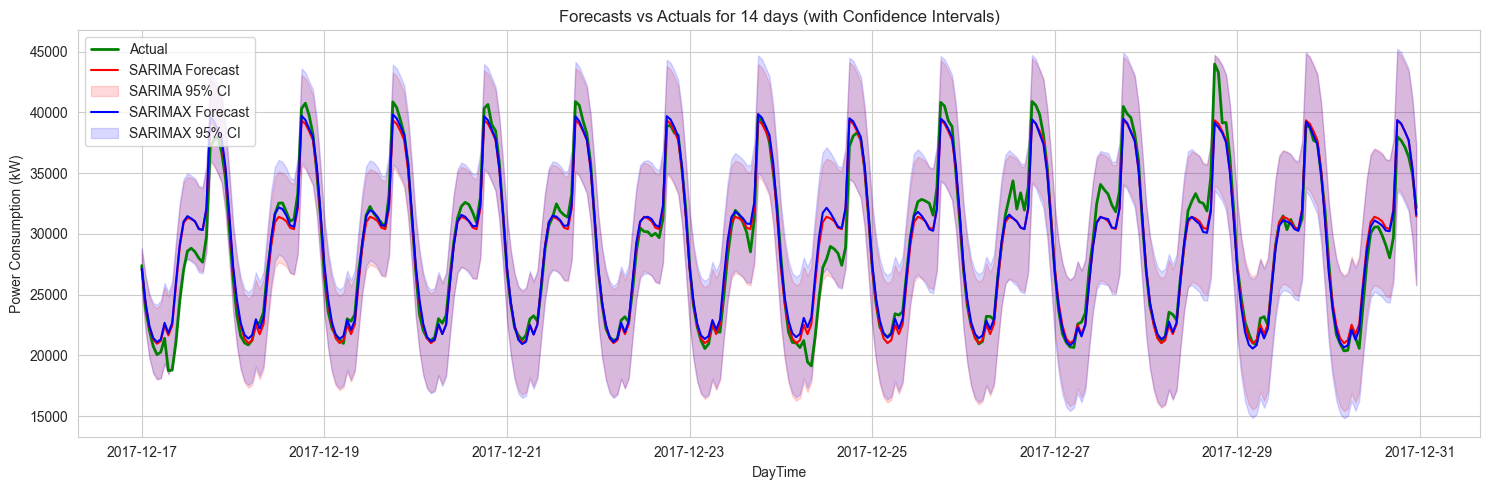

In [30]:
# SARIMA forecast & confidence interval
forecast_obj=results.get_forecast(steps=horizon)
predicted_mean=forecast_obj.predicted_mean
conf_int=forecast_obj.conf_int()

# SARIMAX forecast & confidence interval
forecast_obj_x=sarimax_results.get_forecast(steps=horizon ,exog=x_test)
predicted_mean_x=forecast_obj_x.predicted_mean
conf_int_x=forecast_obj_x.conf_int()

plt.figure(figsize=(15,5))
plt.plot(y_test.index,y_test,label='Actual',color='green',linewidth=2)

plt.plot(y_test.index, predicted_mean, label='SARIMA Forecast', color='red')
plt.fill_between(
    y_test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='red',
    alpha=0.15,
    label='SARIMA 95% CI'
)

plt.plot(y_test.index, predicted_mean_x, label='SARIMAX Forecast', color='blue')
plt.fill_between(
    y_test.index,
    conf_int_x.iloc[:, 0],
    conf_int_x.iloc[:, 1],
    color='blue',
    alpha=0.15,
    label='SARIMAX 95% CI'
)

plt.ylabel('Power Consumption (kW)')
plt.xlabel('DayTime')
plt.title('Forecasts vs Actuals for 14 days (with Confidence Intervals)')
plt.legend()
plt.tight_layout()
plt.show()

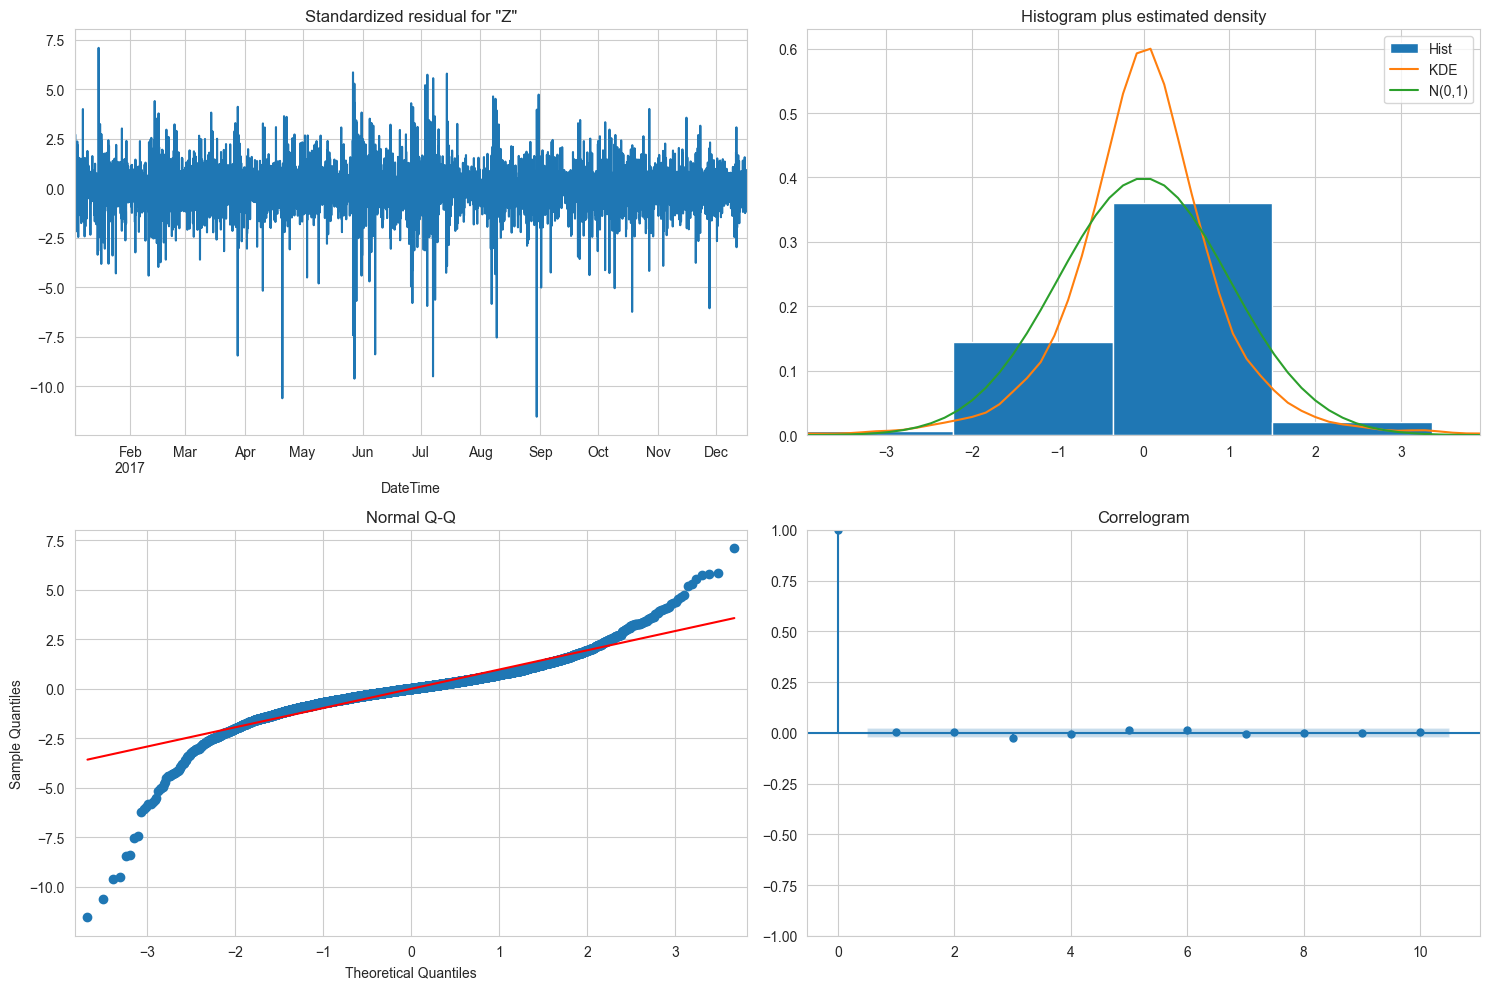

In [31]:
# Dianostic Plots for Model

sarimax_results.plot_diagnostics(figsize=(15,10))
plt.tight_layout()
plt.show()